## Prepare dataset

In [ ]:
from pathlib import Path

DATASET_NAME = "COW_NII_256"
DATA_PATH = "/data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic"
DATA_PATH ="/data/galati/brain_data/"

OUT_DIR = DATA_PATH + "_PREPROCESSED"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils
def img_path_to_brain_path(img_path):
    out_path =img_path.replace("/images","/brain")
    return out_path
def img_path_to_vessel_path(img_path):
    out_path =img_path.replace("/images","/labels")
    return out_path
def img_path_to_weight_path(img_path):
    return None

utils.img_path_to_brain_path = img_path_to_brain_path
utils.img_path_to_vessel_path = img_path_to_vessel_path
utils.img_path_to_weight_path = img_path_to_weight_path

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = "^.*MRA.nii.gz$"
PATH_RULE = ".*/images(Tr|Ts)/.*.nii.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = ['IXI371-IOP-0970-MRA.nii.gz']

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = False

#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = False

### Extract paths

In [9]:
import os

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [10]:
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH, info["train"])
else:
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI002-Guys-0828-MRA_topcow_090.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI012-HH-1211-MRA_topcow_091.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI013-HH-1212-MRA_topcow_092.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI015-HH-1258-MRA_topcow_093.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI016-Guys-0697-MRA_topcow_094.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI017-Guys-0698-MRA_topcow_095.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stoc

### Display examples

In [11]:
import random

from utils import print_bold, load_and_display_middle_slice

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 520 576 184   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.296875   0.296875   0.60000455 1.         1.
 1.         1.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'TE=3.4;Time=101937.067'
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.041193478
quatern_c       : -0.002328013
quatern_d       : 0.9990949
qoffs

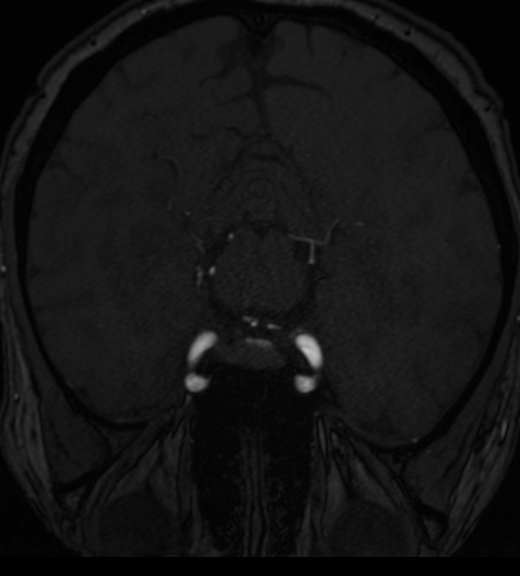

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 100   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.         0.46875    0.46875    0.7999994  0.         0.
  0.         0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'MR'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.027279263
quatern_c       : -0.9994637
quatern_d       : -0.018108742
qoffset_x       : 130.50

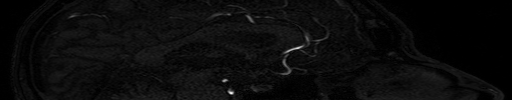

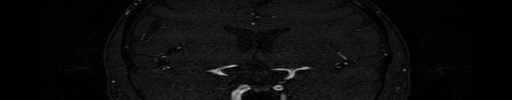

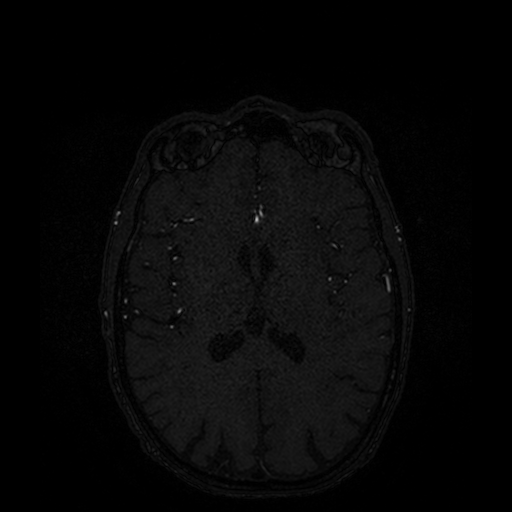

In [12]:
print_bold("[Example 01]")
random.seed(0)
load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)

print_bold("[Example 02]")
random.seed(1)
load_and_display_middle_slice(random.choice(info["train"].paths), axis=[0,1,2], display_header=True)

### Split train/val/test

In [13]:
from utils import is_medical_volume

In total, there are

In [14]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

112

volumes. First, we discard the outliers:

In [15]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs)

112

We have vessel annotations for

In [16]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]

len(HAVE_VESSELs)

112

of them. With a chosen ratio of 70-15-15, we select

In [17]:
COUNT_TEST = 4
COUNT_TEST

4

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [18]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

0

Finally, we randomly split our dataset. 

In [19]:
random.seed(0)

# all the HAVE_VESSELs that have imagesTs in their path
TEST_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if "imagesTs" in img]
print("test: ", [os.path.basename(img) for img in TEST_IMGs])


random.seed(1)
# COUNT_TEST random HAVE_VESSELs that are not in TEST_IMGs
VAL_IMGs = random.sample([img for img in HAVE_VESSELs if img not in TEST_IMGs], COUNT_TEST)
print("val: ")
for img in VAL_IMGs:
    print(img)

TRAIN_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if img not in VAL_IMGs and img not in TEST_IMGs]
print("train: ")
for img in TRAIN_IMGs:
    print(img)

f"Len train: {len(TRAIN_IMGs)}, Len val: {len(VAL_IMGs)}, Len test: {len(TEST_IMGs)}"

test:  ['topcow_mr_whole_000.nii.gz', 'topcow_mr_whole_001.nii.gz', 'topcow_mr_whole_002.nii.gz', 'topcow_mr_whole_003.nii.gz', 'topcow_mr_whole_004.nii.gz', 'topcow_mr_whole_005.nii.gz', 'topcow_mr_whole_006.nii.gz', 'topcow_mr_whole_007.nii.gz', 'topcow_mr_whole_008.nii.gz', 'topcow_mr_whole_009.nii.gz', 'topcow_mr_whole_010.nii.gz', 'topcow_mr_whole_011.nii.gz', 'topcow_mr_whole_012.nii.gz', 'topcow_mr_whole_013.nii.gz', 'topcow_mr_whole_014.nii.gz', 'topcow_mr_whole_015.nii.gz', 'topcow_mr_whole_016.nii.gz', 'topcow_mr_whole_017.nii.gz', 'topcow_mr_whole_018.nii.gz', 'topcow_mr_whole_019.nii.gz', 'topcow_mr_whole_020.nii.gz', 'topcow_mr_whole_021.nii.gz', 'topcow_mr_whole_022.nii.gz', 'topcow_mr_whole_023.nii.gz', 'topcow_mr_whole_024.nii.gz', 'topcow_mr_whole_025.nii.gz', 'topcow_mr_whole_026.nii.gz', 'topcow_mr_whole_027.nii.gz', 'topcow_mr_whole_028.nii.gz', 'topcow_mr_whole_029.nii.gz', 'topcow_mr_whole_030.nii.gz', 'topcow_mr_whole_031.nii.gz', 'topcow_mr_whole_032.nii.gz', 't

'Len train: 18, Len val: 4, Len test: 90'

In [20]:
import pickle


with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Extract spacings and shapes

In [21]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [22]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [23]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE),
    "val": extract_info_and_masks(path_rule=PATH_RULE),
    "test": extract_info_and_masks(path_rule=PATH_RULE),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

In [24]:
try:
    display_info(info["train"], info["val"])
except Exception as e:
     display_info(info["train"])

,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,18,1776,[000.47 000.47 000.80],[000.26 000.26 000.80] - [000.47 000.47 000.80],[367.00 487.50 100.00],[321.00 433.00 092.00] - [653.00 870.00 100.00]
VAL,4,400,[000.47 000.47 000.80],[000.47 000.47 000.80] - [000.47 000.47 000.80],[359.00 497.50 100.00],[350.00 482.00 100.00] - [365.00 512.00 100.00]


In [25]:
SPACING = get_target_spacing(
    info["train"].spacings + info["val"].spacings,
    info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
)

SPACING

array([0.46875   , 0.46875   , 0.79999992])

In [26]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [27]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [28]:
import os
import numpy as np

from utils import print_bold, preprocessing_loop_256

In [29]:
SPACING = np.array([0.46875   , 0.46875   , 0.79999992])

In [30]:
print_bold("Validation")
preprocessing_loop_256(
    info["val"],
    os.path.join(OUT_DIR,"numpy", "val"),
    target_spacing=SPACING,
    save_unique=False,
    new_shape=[256, 256]
)

Validation


  0%|          | 0/4 [00:00<?, ?it/s]

(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46874994 0.4687499  0.799995  ]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875018, 0.79999954), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.93750036, 0.79999954), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


 25%|██▌       | 1/4 [00:05<00:15,  5.05s/it]

Slices processed: 256
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875    0.46875    0.79999995]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875006, 0.79999995), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.9375001, 0.79999995), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


...

Slices processed: 512
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875    0.46875    0.80000013]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875003, 0.7999999), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.93750006, 0.7999999), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


 75%|███████▌  | 3/4 [00:14<00:04,  4.94s/it]

Slices processed: 768
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875024 0.46875003 0.80000025]

=== Resampled ===
Image - Spacing: (0.46875, 0.46874997, 0.7999999), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.9375, 0.93749994, 0.7999999), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


100%|██████████| 4/4 [00:19<00:00,  4.98s/it]

Slices processed: 1024


In [31]:
print_bold("Training")
preprocessing_loop_256(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING,
    save_unique=False,
    new_shape = [256,256]
    
)

Training


  0%|          | 0/18 [00:00<?, ?it/s]

(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875   0.46875   0.7999998]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875003, 0.79999995), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.93750006, 0.79999995), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


  6%|▌         | 1/18 [00:05<01:25,  5.03s/it]

Slices processed: 256
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875    0.46875    0.79999995]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875, 0.79999995), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.9375, 0.79999995), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


...

Slices processed: 4096
(1024, 1024, 92)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.2636701  0.26366898 0.80000114]

=== Resampled ===
Image - Spacing: (0.46862835, 0.4687199, 0.80081815), Shape: (1024, 1024, 92)
Mask  - Shape: (1024, 1024, 92)
Shape verification: OK

=== Downsized ===
Image - Spacing: (1.8745134, 1.8748796, 0.80081815), Shape: (256, 256, 92)
Mask  - Shape: (256, 256, 92)
Got - Image: (256, 256, 92), Mask: (256, 256, 92)


 94%|█████████▍| 17/18 [01:29<00:05,  5.91s/it]

Slices processed: 4352
(1024, 1024, 92)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.26367489 0.26367295 0.8000006 ]

=== Resampled ===
Image - Spacing: (0.4687356, 0.4671517, 0.8086375), Shape: (1024, 1024, 92)
Mask  - Shape: (1024, 1024, 92)
Shape verification: OK

=== Downsized ===
Image - Spacing: (1.8749424, 1.8686068, 0.8086375), Shape: (256, 256, 92)
Mask  - Shape: (256, 256, 92)
Got - Image: (256, 256, 92), Mask: (256, 256, 92)


100%|██████████| 18/18 [01:37<00:00,  5.39s/it]

Slices processed: 4608


In [32]:
print_bold("Testing")
preprocessing_loop_256(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING,
    save_unique=False,
    new_shape = [256,256]
)

Testing


  0%|          | 0/90 [00:00<?, ?it/s]

(560, 640, 219)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.296875  0.296875  0.5999983]

=== Resampled ===
Image - Spacing: (0.46822357, 0.46871313, 0.8013463), Shape: (560, 640, 219)
Mask  - Shape: (560, 640, 219)
Shape verification: OK

=== Downsized ===
Image - Spacing: (1.0242391, 1.1717829, 0.8013463), Shape: (256, 256, 219)
Mask  - Shape: (256, 256, 219)
Got - Image: (256, 256, 219), Mask: (256, 256, 219)


  1%|          | 1/90 [00:14<21:14, 14.33s/it]

Slices processed: 256
(508, 585, 189)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.296875  0.296875  0.5999942]

=== Resampled ===
Image - Spacing: (0.46754596, 0.46874985, 0.802873), Shape: (508, 585, 189)
Mask  - Shape: (508, 585, 189)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.92778647, 1.0711666, 0.802873), Shape: (256, 256, 189)
Mask  - Shape: (256, 256, 189)
Got - Image: (256, 256, 189), Mask: (256, 256, 189)


...

Slices processed: 22528
(450, 571, 181)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.29687503 0.296875   0.6000014 ]

=== Resampled ===
Image - Spacing: (0.4684545, 0.46875003, 0.8007065), Shape: (450, 571, 181)
Mask  - Shape: (450, 571, 181)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.8234552, 1.0455322, 0.8007065), Shape: (256, 256, 181)
Mask  - Shape: (256, 256, 181)
Got - Image: (256, 256, 181), Mask: (256, 256, 181)


 99%|█████████▉| 89/90 [14:03<00:09,  9.04s/it]

Slices processed: 22784
(406, 533, 181)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.328125  0.328125  0.6000001]

=== Resampled ===
Image - Spacing: (0.46872774, 0.46872914, 0.8000844), Shape: (406, 533, 181)
Mask  - Shape: (406, 533, 181)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.7433729, 0.9759087, 0.8000844), Shape: (256, 256, 181)
Mask  - Shape: (256, 256, 181)
Got - Image: (256, 256, 181), Mask: (256, 256, 181)


100%|██████████| 90/90 [14:11<00:00,  9.46s/it]

Slices processed: 23040


In [33]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

In [34]:
#REMEMBER TO START FROM 0 !

In [35]:
import os
from pathlib import Path
import shutil 

def rename_dataset(DATASET_PATH_RENAMED, OUTPUT_PATH_RENAMED, counter=0):
    print(f"Starting from counter: {counter+1}")
    # DELETE OUTPUT FOLDER IF EXISTS
    if os.path.exists(OUTPUT_PATH_RENAMED):
        shutil.rmtree(OUTPUT_PATH_RENAMED)
    
    Path(OUTPUT_PATH_RENAMED).mkdir(parents=True, exist_ok=True)

    print("Number of subjects: ", len(os.listdir(DATASET_PATH_RENAMED))/3)
    os.listdir(DATASET_PATH_RENAMED)

    dict_id = {}

    for img in os.listdir(DATASET_PATH_RENAMED):
        patient_id = img.split("_")[0]
        if patient_id not in dict_id:
            counter += 1
            dict_id[patient_id] = str(counter).zfill(3)
        # copy to output folder and rename\
        print("Renaming ", img, " to ", dict_id[patient_id] + "_" + img)
        shutil.copy(os.path.join(DATASET_PATH_RENAMED, img), os.path.join(OUTPUT_PATH_RENAMED, dict_id[patient_id] + "_" + img))
        #os.rename(os.path.join(DATASET_PATH_RENAMED, img), os.path.join(OUTPUT_PATH_RENAMED, dict_id[patient_id] + "_" + img))
    return counter
tr_counter = rename_dataset(os.path.join(OUT_DIR, "numpy", "train"), os.path.join(OUT_DIR, "numpy_renamed", "train"), -1)
vl_counter = rename_dataset(os.path.join(OUT_DIR, "numpy", "val"), os.path.join(OUT_DIR, "numpy_renamed", "val"), tr_counter)
rename_dataset(os.path.join(OUT_DIR, "numpy", "test"), os.path.join(OUT_DIR, "numpy_renamed", "test"), vl_counter)

Starting from counter: 0
Number of subjects:  18.0
Renaming  IXI002-Guys-0828-MRA_topcow_090_ToF.nii.gz  to  000_IXI002-Guys-0828-MRA_topcow_090_ToF.nii.gz
Renaming  IXI002-Guys-0828-MRA_topcow_090_brain_mask.nii.gz  to  000_IXI002-Guys-0828-MRA_topcow_090_brain_mask.nii.gz
Renaming  IXI002-Guys-0828-MRA_topcow_090_vessel.nii.gz  to  000_IXI002-Guys-0828-MRA_topcow_090_vessel.nii.gz
Renaming  IXI012-HH-1211-MRA_topcow_091_ToF.nii.gz  to  001_IXI012-HH-1211-MRA_topcow_091_ToF.nii.gz
Renaming  IXI012-HH-1211-MRA_topcow_091_brain_mask.nii.gz  to  001_IXI012-HH-1211-MRA_topcow_091_brain_mask.nii.gz
Renaming  IXI012-HH-1211-MRA_topcow_091_vessel.nii.gz  to  001_IXI012-HH-1211-MRA_topcow_091_vessel.nii.gz
Renaming  IXI015-HH-1258-MRA_topcow_093_ToF.nii.gz  to  002_IXI015-HH-1258-MRA_topcow_093_ToF.nii.gz
Renaming  IXI015-HH-1258-MRA_topcow_093_brain_mask.nii.gz  to  002_IXI015-HH-1258-MRA_topcow_093_brain_mask.nii.gz
Renaming  IXI015-HH-1258-MRA_topcow_093_vessel.nii.gz  to  002_IXI015-HH-12

22

In [40]:
import os
import re
from pathlib import Path

def rename_files(directory):
    """
    Rename files by incrementing the prefix number (022, 023, 024, etc.)
    """
    # Get all files in the directory
    files = sorted([f for f in Path(directory).iterdir() if f.is_file()])
    
    # Group files by their sequence number to handle pairs/triplets together
    file_groups = {}
    for file in files:
        # Extract the sequence number (e.g., '000' from '022_topcow_mr_whole_000_ToF.nii.gz')
        match = re.search(r'_(\d{3})_', file.name)
        if match:
            seq_num = match.group(1)
            if seq_num not in file_groups:
                file_groups[seq_num] = []
            file_groups[seq_num].append(file)
    
    # Process each group
    sorted_seq_nums = sorted(file_groups.keys())
    for i, seq_num in enumerate(sorted_seq_nums):
        new_prefix = str(22 + i).zfill(3)  # Start at 022, then 023, 024, etc.
        
        # Process all files in this group (ToF, brain_mask, vessel)
        for file in file_groups[seq_num]:
            # Replace old prefix (022) with new prefix while keeping the rest of filename
            new_name = re.sub(r'^022_', f'{new_prefix}_', file.name)
            new_path = file.parent / new_name
            
            # Print the renaming operation
            print(f"Renaming: {file.name} -> {new_name}")
            
            # Uncomment the following line to actually perform the rename
            file.rename(new_path)

rename_files('/data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic_PREPROCESSED/numpy_renamed/test')

Renaming: 022_topcow_mr_whole_000_ToF.nii.gz -> 022_topcow_mr_whole_000_ToF.nii.gz
Renaming: 022_topcow_mr_whole_000_brain_mask.nii.gz -> 022_topcow_mr_whole_000_brain_mask.nii.gz
Renaming: 022_topcow_mr_whole_000_vessel.nii.gz -> 022_topcow_mr_whole_000_vessel.nii.gz
Renaming: 022_topcow_mr_whole_001_ToF.nii.gz -> 023_topcow_mr_whole_001_ToF.nii.gz
Renaming: 022_topcow_mr_whole_001_brain_mask.nii.gz -> 023_topcow_mr_whole_001_brain_mask.nii.gz
Renaming: 022_topcow_mr_whole_001_vessel.nii.gz -> 023_topcow_mr_whole_001_vessel.nii.gz
Renaming: 022_topcow_mr_whole_002_ToF.nii.gz -> 024_topcow_mr_whole_002_ToF.nii.gz
Renaming: 022_topcow_mr_whole_002_brain_mask.nii.gz -> 024_topcow_mr_whole_002_brain_mask.nii.gz
Renaming: 022_topcow_mr_whole_002_vessel.nii.gz -> 024_topcow_mr_whole_002_vessel.nii.gz
Renaming: 022_topcow_mr_whole_003_ToF.nii.gz -> 025_topcow_mr_whole_003_ToF.nii.gz
Renaming: 022_topcow_mr_whole_003_brain_mask.nii.gz -> 025_topcow_mr_whole_003_brain_mask.nii.gz
Renaming: 022

In [ ]:
print("All done!")

print(f"PREPROCESSING DONE! Dataset saved in {OUT_DIR}/numpy_renamed")

All done!
